<a href="https://colab.research.google.com/github/Manvi190502/ml/blob/main/Hierarichal_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
iris=load_iris()

In [5]:
df=pd.DataFrame(iris.data)

In [7]:
df.columns=iris.feature_names

In [8]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
#standardization
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(df)

In [11]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(X)

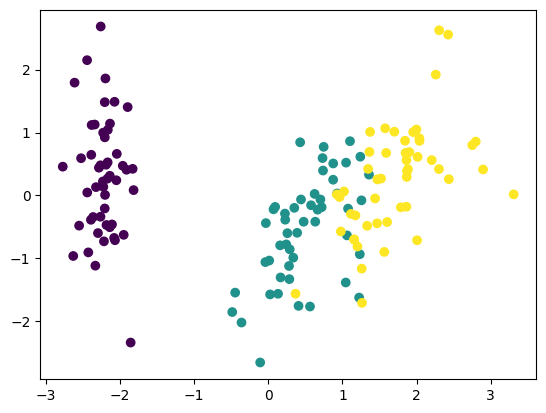

In [13]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=iris.target)

Text(0, 0.5, 'Euclidean distance')

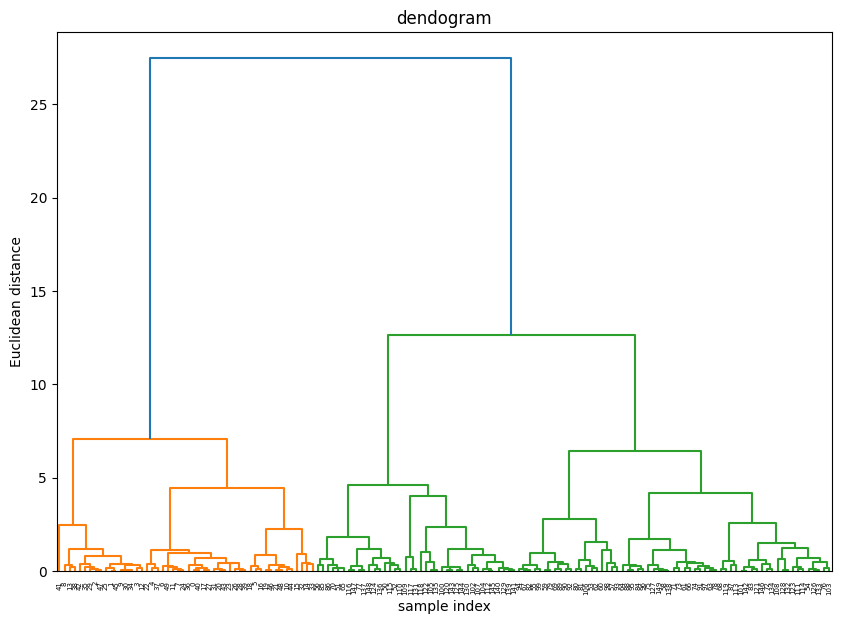

In [15]:
## Agglomerative Clustering
import scipy.cluster.hierarchy as sc
plt.figure(figsize=(10,7))
plt.title("dendogram")
sc.dendrogram(sc.linkage(x_pca,method='ward'))
plt.xlabel("sample index")
plt.ylabel("Euclidean distance")

In [20]:
from sklearn.cluster import AgglomerativeClustering
ac=AgglomerativeClustering(n_clusters=2, linkage='ward', metric='euclidean')
ac.fit_predict(x_pca)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

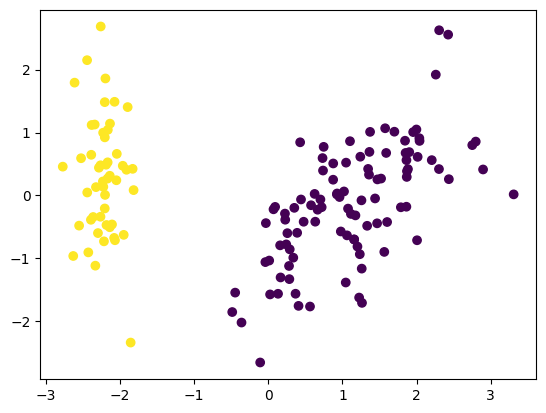

In [21]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=ac.labels_)

In [22]:
from sklearn.metrics import silhouette_score
silhouette_coefficients = []
for k in range(2,11):
  agglo=AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
  agglo.fit_predict(x_pca)
  silhouette_coefficients.append(silhouette_score(x_pca, agglo.labels_))

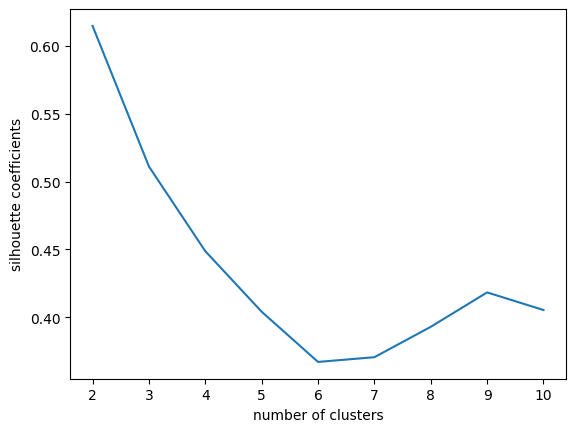

In [23]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("number of clusters")
plt.ylabel("silhouette coefficients")
plt.show()